In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
sys.path.append("../")
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch, Dataset
from tqdm import tqdm

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"

BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"


sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)

X_pixel = np.concatenate([sig_pixel_spacetime, bg_pixel_spacetime], axis=0)
X_mppc = np.concatenate([sig_mppc_spacetime, bg_mppc_spacetime], axis=0)
y = np.concatenate(
    [np.ones(sig_pixel_spacetime.shape[0]), np.zeros(bg_pixel_spacetime.shape[0])], axis=0
)


# --------------------------------
# Functions to convert MPPC and pixel IDs to positions in space
# --------------------------------
from sklearn.model_selection import train_test_split

X_pixel_train, X_pixel_val, X_mppc_train, X_mppc_val, y_train, y_val = train_test_split(
    X_pixel, X_mppc, y, test_size=0.2, random_state=42, stratify=y
)

from torch_src.pre_processing.graph_batching import (
    batch_full_events_to_graphs)

train_graphs = batch_full_events_to_graphs(
    X_mppc_train, X_pixel_train, y_train
)
val_graphs = batch_full_events_to_graphs(
    X_mppc_val, X_pixel_val, y_val
)
del X_mppc, X_pixel, y, X_pixel_train, X_pixel_val, X_mppc_train, X_mppc_val, y_train, y_val
del sig_pixel_spacetime, sig_mppc_spacetime, bg_pixel_spacetime, bg_mppc_spacetime

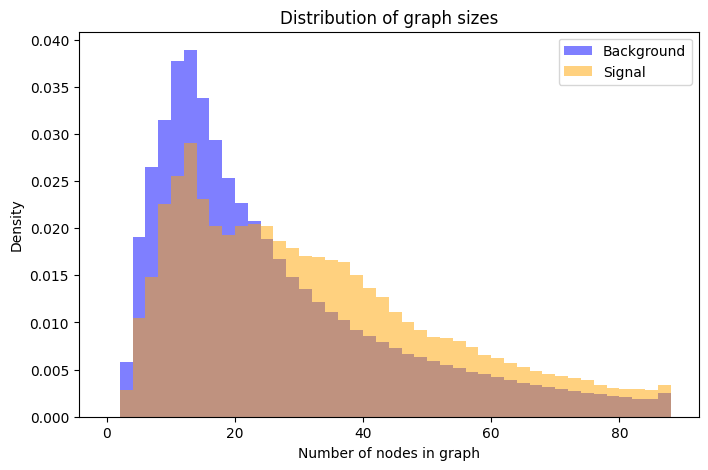

In [2]:
graph_size = np.array([g.num_nodes for g in train_graphs + val_graphs])
graph_labels = np.array([g.y.item() for g in train_graphs + val_graphs])
x_max = np.percentile(graph_size, 95).astype(int)
x_max = (x_max // 2 + 1) * 2  # Round up to nearest 2
bins = np.linspace(0, x_max, x_max // 2 + 1) 
fig, ax = plt.subplots(figsize=(8, 5), )
ax.hist(
    graph_size[graph_labels == 0],
    bins=bins,
    alpha=0.5,
    label="Background",
    color="blue",
    density=True,
)
ax.hist(
    graph_size[graph_labels == 1],
    bins=bins,
    alpha=0.5,
    label="Signal",
    color="orange",
    density=True,
)
ax.set_xlabel("Number of nodes in graph")
ax.set_ylabel("Density")
ax.set_title("Distribution of graph sizes")
ax.legend()
plt.savefig(f"{PLOTS_DIR}/graph_size_distribution.png")

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.nn import GCNConv, GATConv, GraphConv, SAGEConv
from torch_geometric.nn import BatchNorm, LayerNorm
from torch_scatter import scatter_mean, scatter_max, scatter_add, scatter_std
import numpy as np
from typing import Optional, List, Tuple
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score


class SimpleGraphClassifier(nn.Module):
    """
    Simplified graph classifier that's easier to use and debug.
    """

    def __init__(
        self,
        node_input_dim: int,
        hidden_dim: int = 64,
        num_conv_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()

        # Node feature processing
        self.node_projection = nn.Linear(node_input_dim, hidden_dim)

        # Graph convolution layers
        self.conv_layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        for _ in range(num_conv_layers):
            self.conv_layers.append(GCNConv(hidden_dim, hidden_dim))
            self.batch_norms.append(BatchNorm(hidden_dim))

        # Multi-scale pooling
        self.dropout = dropout

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),  # 3x for multi-pooling
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(
        self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor
    ) -> torch.Tensor:
        """
        Simplified forward pass.
        """
        # Project node features
        x = F.relu(self.node_projection(x))

        # Apply convolutions
        for conv, bn in zip(self.conv_layers, self.batch_norms):
            x_new = conv(x, edge_index)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            x = x + x_new  # Residual connection

        # Multi-scale pooling
        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)
        sum_pool = global_add_pool(x, batch)

        # Combine pooled features
        graph_features = torch.cat([mean_pool, max_pool, sum_pool], dim=-1)

        # Final classification
        logits = self.classifier(graph_features)
        return torch.sigmoid(logits.squeeze(-1))

In [5]:
def train_graph_classifier(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 100,
    initial_lr : float = 0.001
):
    """
    Train a graph-level classifier.

    Args:
        train_graphs: Training graphs with graph-level labels
        val_graphs: Validation graphs with graph-level labels
        batch_size: Batch size for training
        num_epochs: Number of training epochs
        lr: Learning rate
    """

    # Create datasets and loaders
    class FocalLoss(nn.Module):
        """
        Focal Loss for addressing class imbalance.
        """

        def __init__(self, alpha=0.5, gamma=2.0):
            super().__init__()
            self.alpha = alpha
            self.gamma = gamma

        def forward(self, inputs, targets):
            bce_loss = F.binary_cross_entropy(inputs, targets, reduction="none")
            p_t = torch.where(targets == 1, inputs, 1 - inputs)
            alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)

            focal_loss = alpha_t * (1 - p_t) ** self.gamma * bce_loss
            return focal_loss.mean()

    # Create model
    node_input_dim = train_graphs[0].x.shape[1]

    model = SimpleGraphClassifier(
        node_input_dim=node_input_dim, hidden_dim=32, num_conv_layers=5, dropout=0.2
    )
    print(
        f"Model initialized with {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters."
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
    criterion = FocalLoss(alpha=0.5, gamma=2.0)

    # Training loop
    train_losses, val_losses = [], []
    train_aucs, val_aucs = [], []

    best_val_auc = 0.0

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            optimizer.zero_grad()

            predictions = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(predictions, batch.y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(predictions.detach().cpu().numpy())
            train_labels.extend(batch.y.cpu().numpy())
        train_auc = roc_auc_score(train_labels, train_preds)

        print(
            f"Epoch {epoch+1}/{num_epochs} - Training loss: {train_loss/len(train_loader):.4f}, AUC: {train_auc:.4f}"
        )

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                predictions = model(batch.x, batch.edge_index, batch.batch)
                loss = criterion(predictions, batch.y)

                val_loss += loss.item()
                val_preds.extend(predictions.cpu().numpy())
                val_labels.extend(batch.y.cpu().numpy())

        # Calculate metrics
        val_auc = roc_auc_score(val_labels, val_preds)

        print(
            f"Epoch {epoch+1}/{num_epochs} - Validation loss: {val_loss/len(val_loader):.4f}, AUC: {val_auc:.4f}"
        )

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_aucs.append(train_auc)
        val_aucs.append(val_auc)

        scheduler.step(val_loss)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), f"{MODEL_DIR}/best_graph_classifier.pth")

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train AUC: {train_auc:.4f}, Val AUC: {val_auc:.4f}")

    print(f"Best validation AUC: {best_val_auc:.4f}")
    return model, {"train_aucs": train_aucs, "val_aucs": val_aucs}

In [ ]:
train_loader = DataLoader(train_graphs, batch_size=512, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=512, shuffle=False)

model, aucs = train_graph_classifier(train_loader, val_loader, num_epochs=30, initial_lr=0.001)

Model initialized with 9537 trainable parameters.


Epoch 1/30: 100%|██████████| 1861/1861 [03:27<00:00,  8.99it/s]


Epoch 1/30 - Training loss: 0.0360, AUC: 0.8306
Epoch 1/30 - Validation loss: 0.0294, AUC: 0.9095
Epoch 0: Train AUC: 0.8306, Val AUC: 0.9095


Epoch 2/30: 100%|██████████| 1861/1861 [04:06<00:00,  7.54it/s]


Epoch 2/30 - Training loss: 0.0289, AUC: 0.9035
Epoch 2/30 - Validation loss: 0.0279, AUC: 0.9223


...

Epoch 6/30: 100%|██████████| 1861/1861 [04:23<00:00,  7.07it/s]


Epoch 6/30 - Training loss: 0.0235, AUC: 0.9398
Epoch 6/30 - Validation loss: 0.0225, AUC: 0.9477


Epoch 7/30: 100%|██████████| 1861/1861 [04:39<00:00,  6.66it/s]


Epoch 7/30 - Training loss: 0.0227, AUC: 0.9444
Epoch 7/30 - Validation loss: 0.0208, AUC: 0.9542


Epoch 8/30:  37%|███▋      | 695/1861 [02:03<03:14,  6.00it/s]

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(aucs["train_aucs"], label="Train AUC")
ax.plot(aucs["val_aucs"], label="Validation AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_title("Training and Validation AUC over Epochs")
ax.legend()
plt.savefig(f"{PLOTS_DIR}/graph_classifier_aucs.png")